<a href="https://colab.research.google.com/github/roohiverma-05/CMB-Analysis/blob/main/CMB_Spectral_Distortions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python based Simulator on Studying the Thermodynamic State of the Early-Age Universe under The Influence of μ- and y- Distortions

## Defining the State of the Universe at any given redshift (z)

In [ ]:
class Universe_Parameters:
  def __init__(self):
    # Constants at z=0:
    self.T_0 = 2.725 # Present temperature of the Universe.
    self.n_gamma_0 = 411 # Present Photon Number Density

  def scale_factor(self, z):
    return 1 / (1+z)
  def Temperature(self, z):
    return self.T_0 * (1 + z)
  def photon_number_density(self, z):
    return self.n_gamma_0 * (1 + z)**3

# Testing for some z:
z_test = 2e6
Universe_state = Universe_Parameters()
print(f"Universe at z = {z_test:,.0f} ---")
print(f"Scale Factor (a): {Universe_state.scale_factor(z_test):.2e}")
print(f"CMB Temperature (T):  {Universe_state.Temperature(z_test):,.0f} K")
print(f"Photon Density (n):   {Universe_state.photon_number_density(z_test):.2e} photons/cm^3")

Universe at z = 2,000,000 ---
Scale Factor (a): 5.00e-07
CMB Temperature (T):  5,450,003 K
Photon Density (n):   3.29e+21 photons/cm^3


## The Physics Aspect, the Timeline

While creating this pipeline our few particles of interests include electrons and photons. The effects of Compton scattering, Bremsstrahlung are taken into consideration.

During the thermalization era, mu-distortion era and the y-distortion era the various quantum mechanical effects like Compton scattering, bremsstrahlung, etc show the interactions between the photons and electrons. There effects lead to distortions in the cosmic microwave background which ideally should have shown a black body curve. The thermalization era shows an ideal planckian distribution.
The mu distortion era show the bose einstein distribution through the plasma due to a deficit of low-frequency photons measured by chemical potential mu.
The y distortion era shows a dominance of high energy photons because of Sunyaev Zeldovich effects.

At the thermalization era the photons generated were all of a wide spectrum of frequencies but the number density of the photons are balanced such that they follow a planckian distribution, this is because of a thermal equilibrium between the photons and electrons. As the universe expands the density decreases and the particles get further apart avrious processes like Bremsstrahlung effect's intensity decreases by a factor of (1+z)^6 as the rate of bremsstrahlung is (n_e)^2. After a particular z the process stops completely and low energy photons stop emitting leaving a distribution skewed towards higher frequencies. This leads to mu distortions. The y distortions were a result of Inverse Compton Scattering which is still seen as the CMB Photons pass through galactic clouds and undergo the quantum mechanical effects to create a y distortion. The rate of collison is n_e​σ_T​c where the constant is Thomson cross-section constant.

## The Mathematical Aspects

We are working with a large number of Photons. We cannot track a single photon. We need to track the entire spectrum, individual photons can't be tracked. Spectrum is analysed as a fluid. The Kompaneet's differential equation determines the evolution of a photon spectrum when scattering off a hot electron gas. This is a result of Bose-Einstein Statistics!
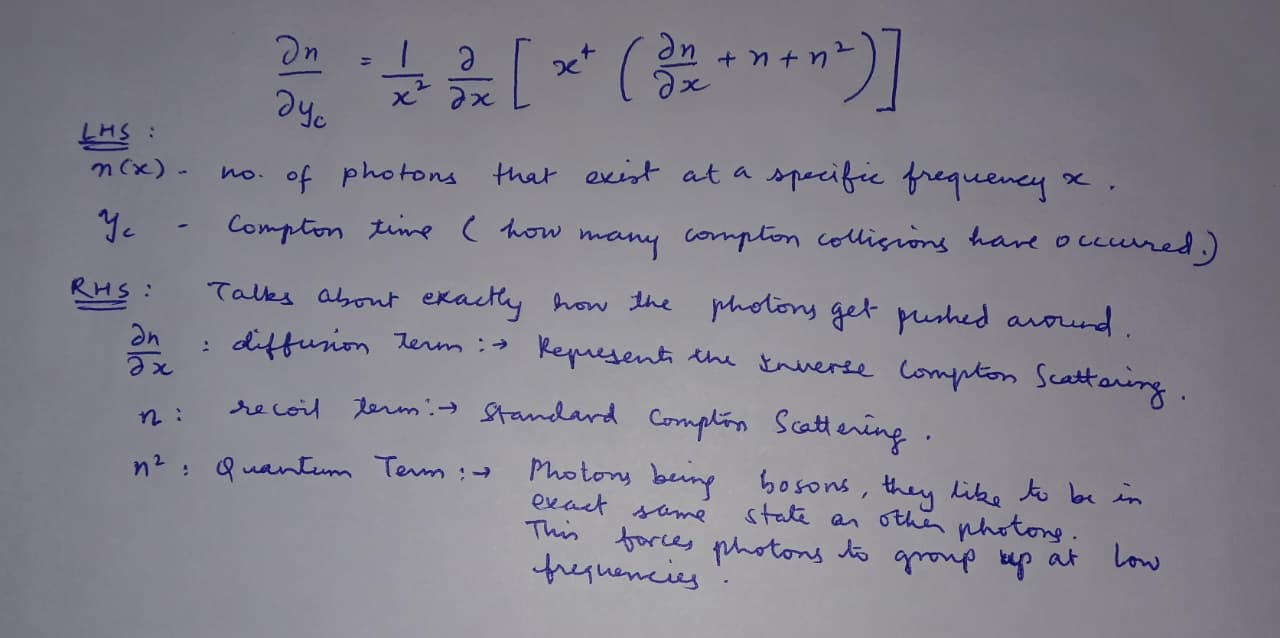

This formula gives the rate of photon occupation number with respect to compton time is 0 when the right hand side n is put as a function which mimics a perfect black body. Changes due to mu and y can be mapped into this differential equation.

The discretization of this equation is essential as computers don't understand continuous calculus. We can discretize it through a **Finite Difference Model.**

As we know that distortions occur because of energy injections given to the universe which has to be taken into account into the equation.

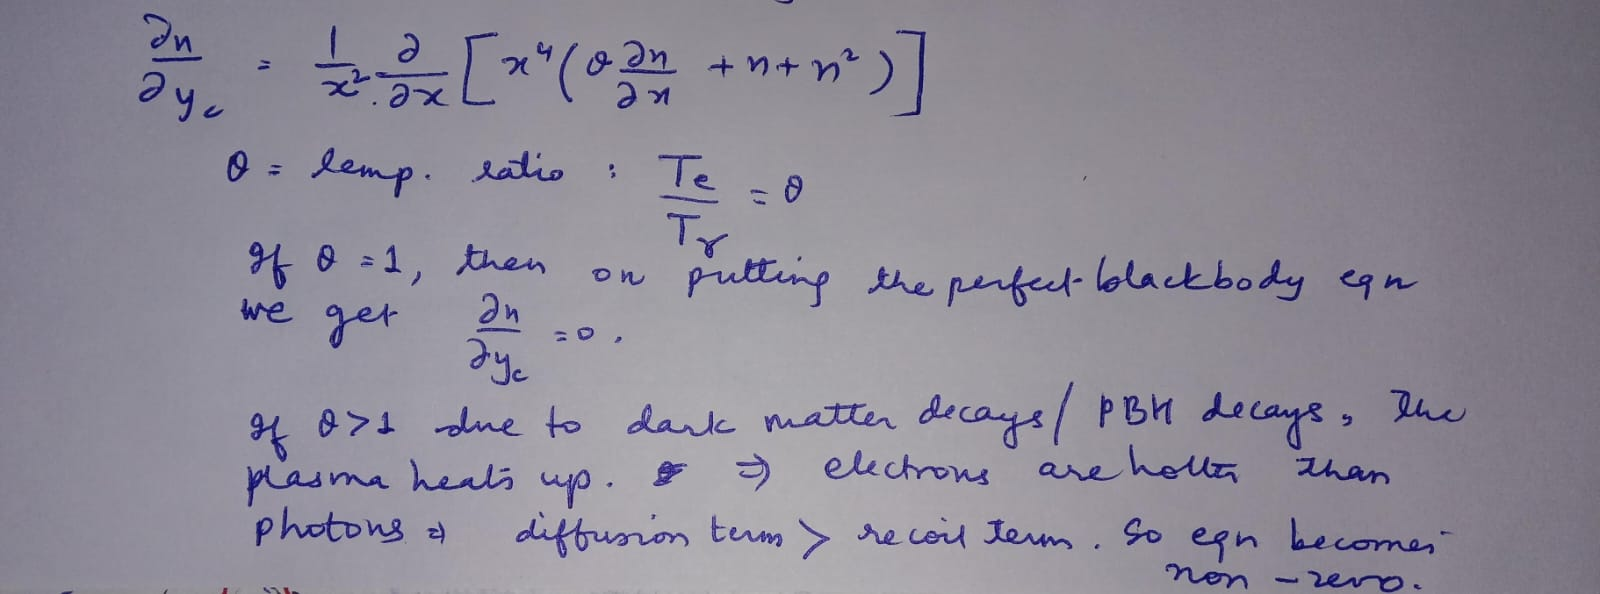

In [4]:
import matplotlib.pyplot as plt
import numpy as np

<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_140/4264610256.py:36: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Intensity Shift ($\Delta I$)", fontsize=12)


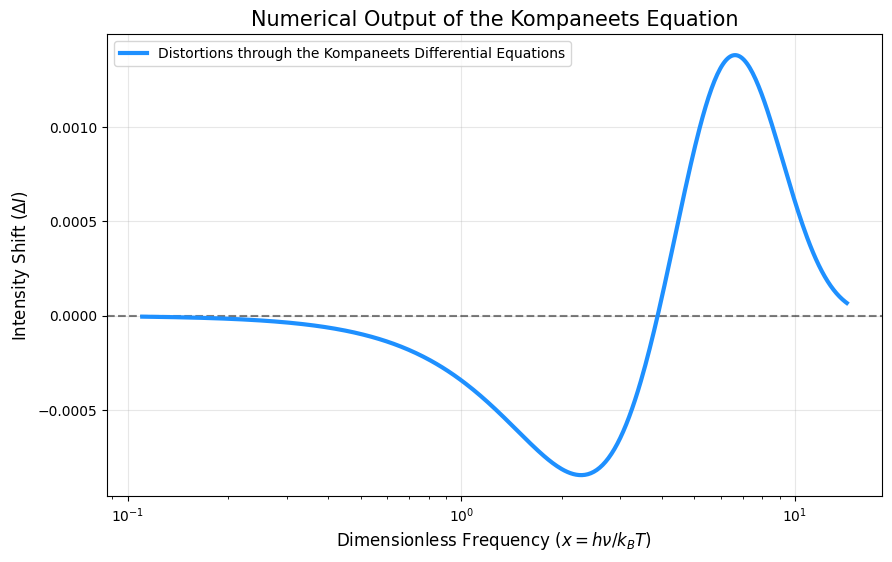

In [6]:
# Using a log space to fit the whole spectra for CMB easily.
x = np.logspace(-1, 1.2, 500)

# Defining perfect black body function:
n_initial = 1/(np.exp(x) - 1.0)

# The Kompaneet's equation
def Kompaneets(n_current, x_grid, theta):
  dn_dx = np.gradient(n_current, x_grid)

  inner_term = ((x_grid)**4 * (theta * dn_dx + n_current**2 + n_current))

  derivative_inner = np.gradient(inner_term, x_grid)

  dn_dyc = (1.0 /x_grid)**2*derivative_inner

  return dn_dyc

theta_injected = 1.01
dyc = 0.02

dn_dyc = Kompaneets(n_initial, x, theta_injected)

# The new distorted spectrum:
n_final = n_initial + (dn_dyc * dyc)

distortion = x**3 * (n_final - n_initial)

# Plotting it!
plt.figure(figsize=(10,6))
plt.axhline(0, color = 'black', linestyle ='--', alpha = 0.5)
plt.plot(x[10:-10], distortion[10:-10], color='dodgerblue', linewidth=3, label="Distortions through the Kompaneets Differential Equations")

plt.title("Distortions", fontsize=15)
plt.xlabel(" Frequency ($x = h\\nu / k_B T$)", fontsize=12)
plt.ylabel("Intensity Shift ($\Delta I$)", fontsize=12)
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

On making considerations bremsstrahlung raditions should also be taken into account. On doing this our model is complete for early universe era such as the thermalization era. This will ensure to stabilize the graph back to a Planckian distribution

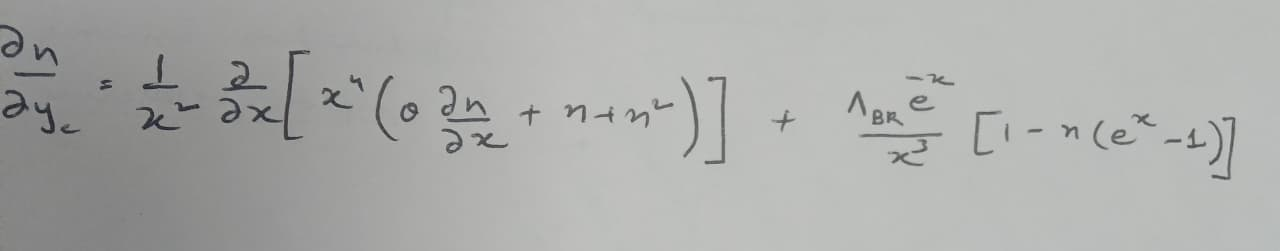

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_140/2717853220.py:41: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Intensity Shift ($\Delta I$)", fontsize=12)


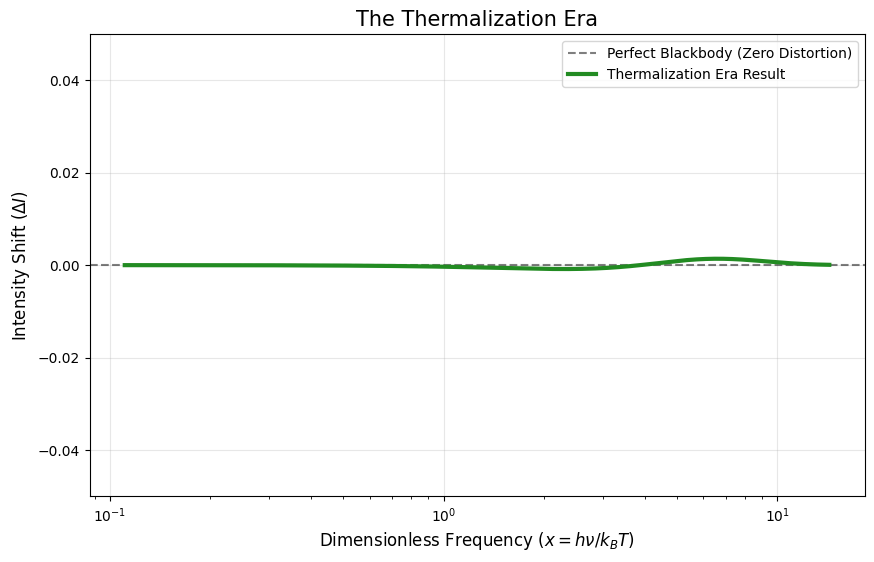

In [9]:
# Using a log space to fit the whole spectra for CMB easily.
x = np.logspace(-1, 1.2, 500)

# Defining perfect black body function:
n_initial = 1/(np.exp(x) - 1.0)

# The Kompaneet's equation
def Kompaneets(n_current, x_grid, theta, K_BR):
  dn_dx = np.gradient(n_current, x_grid)
  inner_term = ((x_grid)**4 * (theta * dn_dx + n_current**2 + n_current))
  derivative_inner = np.gradient(inner_term, x_grid)
  compton_term = (1.0 /x_grid)**2*derivative_inner

  K_BR_cofficients = (K_BR * np.exp(-x_grid)) / (x_grid**3)
  KBR_funtion = 1.0 - (n_current * (np.exp(x_grid) - 1.0))
  bremsstrahlung_term = K_BR_cofficients * KBR_funtion

  dn_dyc = compton_term + bremsstrahlung_term
  return dn_dyc


theta_injected = 1.01
bremsstrahlung_cofficient = 50
dyc = 0.02

dn_dyc = Kompaneets(n_initial, x, theta_injected, K_BR = bremsstrahlung_cofficient)

# The new distorted spectrum:
n_final = n_initial + (dn_dyc * dyc)

distortion = x**3 * (n_final - n_initial)

# Plotting it!
plt.figure(figsize=(10, 6))
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label="Perfect Blackbody (Zero Distortion)")

plt.plot(x[10:-10], distortion[10:-10], color='forestgreen', linewidth=3, label="Thermalization Era Result")

plt.title("The Thermalization Era", fontsize=15)
plt.xlabel("Dimensionless Frequency ($x = h\\nu / k_B T$)", fontsize=12)
plt.ylabel("Intensity Shift ($\Delta I$)", fontsize=12)
plt.xscale('log')

# Lock the y-axis so we can see how flat it really is compared to the y-distortion
plt.ylim(-0.05, 0.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()